# Load in NLR DB data for swift creek

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
def remove_header(df):
    """Deletes first row of df and sets column names to new first row
    """
    df = df[1:]
    df.columns = df.iloc[0]
    df = df[1:]
    return df

In [4]:
def drop_nan_columns(df):
    """Drops columns with all NaN values
    """
    df = df.dropna(axis=1, how='all')
    
    return df

In [5]:
def floatify_columns(df):
    # Convert all columns to float
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def rename_columns(df):
    map_name = {"Temperature": "Air Temperature"}
    # Map columns to new names
    df = df.rename(columns=map_name)
    return df

In [6]:
def make_datetime(df):
    # Combine "Year, Month, Day, Hour, Minute" into a single datetime column
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
    return df

In [7]:
def smooth_wind_direction(df):
    """Wind direction ranges from 0 to 360 degrees. This function converts the wind direction to a sine value, which is useful for machine learning models.
    """
    df['Smooth Wind Direction'] = np.sin(2 * np.pi * df['Wind Direction'] / 360) #TODO is this correct?

    return df

In [15]:
def load_one(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    df = remove_header(df)
    df = drop_nan_columns(df)
    df = floatify_columns(df)
    df = rename_columns(df)
    df = make_datetime(df)
    df = smooth_wind_direction(df)
    return df

In [16]:
def load_data(folder_path):
    dataframes = []
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = load_one(file_path)
            dataframes.append(df)
    # Concatenate all dataframes into one
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

In [17]:
df = load_data('NLRDB')

In [18]:
df

1,Year,Month,Day,Hour,Minute,Air Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
0,2018,1,1,0,0,0.5,1.45,0.117,0.63,0,...,71.11,170.93,0.95,0.14,1030,1.0,3,3.4,2018-01-01 00:00:00,0.052336
1,2018,1,1,0,15,0.4,1.45,0.117,0.63,0,...,71.62,172.52,0.95,0.14,1030,1.0,4,3.4,2018-01-01 00:15:00,0.069756
2,2018,1,1,0,30,0.3,1.45,0.117,0.63,0,...,72.14,172.80,0.95,0.14,1030,1.0,5,3.4,2018-01-01 00:30:00,0.087156
3,2018,1,1,0,45,0.1,1.45,0.105,0.63,0,...,68.45,171.61,0.95,0.14,1030,1.0,6,3.4,2018-01-01 00:45:00,0.104528
4,2018,1,1,1,0,0.0,1.45,0.105,0.63,0,...,68.94,169.46,0.95,0.14,1030,1.0,7,3.4,2018-01-01 01:00:00,0.121869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280315,2025,12,31,22,45,8.4,1.41,0.028,0.63,0,...,91.86,156.53,0.89,0.15,1017,0.8,22,1.5,2025-12-31 22:45:00,0.374607
280316,2025,12,31,23,0,8.3,1.41,0.028,0.63,0,...,92.48,159.68,0.90,0.15,1017,0.8,22,1.5,2025-12-31 23:00:00,0.374607
280317,2025,12,31,23,15,8.1,1.41,0.028,0.63,0,...,93.75,162.77,0.90,0.15,1017,0.8,22,1.5,2025-12-31 23:15:00,0.374607
280318,2025,12,31,23,30,8.0,1.41,0.028,0.63,0,...,94.38,165.74,0.90,0.15,1017,0.8,22,1.5,2025-12-31 23:30:00,0.374607


In [24]:
df.to_csv('NLRDB_combined.csv', index=False)

# Feature analysis

- Convert Wind Direction to a sinusoidal value (currently 0 to 360)

In [19]:
df.describe()

1,Year,Month,Day,Hour,Minute,Air Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
count,280320.000000,280320.000000,280320.000000,280320.000000,280320.00000,280320.000000,280320.000000,280320.00000,280320.000000,280320.000000,...,280320.000000,280320.000000,280320.000000,280320.00000,280320.000000,280320.000000,280320.000000,280320.000000,280320,280320.000000
mean,2021.500000,6.526027,15.720548,11.500000,22.50000,21.311759,1.207014,0.14761,0.620933,52.841103,...,76.369298,89.718906,0.946363,0.15689,1012.012925,3.057490,162.021129,1.744695,2021-12-31 22:54:18.493150,0.204868
min,2018.000000,1.000000,1.000000,0.000000,0.00000,-10.600000,0.060000,0.01100,0.600000,0.000000,...,12.390000,6.830000,0.830000,0.10000,992.000000,0.200000,0.000000,0.000000,2018-01-01 00:00:00,-1.000000
25%,2019.750000,4.000000,8.000000,5.750000,11.25000,15.300000,1.010000,0.07800,0.620000,0.000000,...,60.090000,55.410000,0.930000,0.15000,1008.000000,1.900000,108.000000,1.000000,2019-12-31 23:56:15,-0.190809
50%,2021.500000,7.000000,16.000000,11.500000,22.50000,22.700000,1.230000,0.12500,0.620000,0.000000,...,82.140000,89.280000,0.950000,0.16000,1011.000000,3.200000,158.000000,1.500000,2021-12-31 23:52:30,0.275637
75%,2023.250000,10.000000,23.000000,17.250000,33.75000,27.300000,1.410000,0.18800,0.630000,102.000000,...,96.570000,124.100000,0.960000,0.16000,1015.000000,4.100000,199.000000,2.300000,2023-12-31 23:48:45,0.681998
max,2025.000000,12.000000,31.000000,23.000000,45.00000,44.700000,2.230000,1.24400,0.640000,465.000000,...,100.000000,173.240000,0.990000,0.80000,1037.000000,7.400000,360.000000,8.400000,2025-12-31 23:45:00,1.000000
std,2.291292,3.447857,8.796263,6.922199,16.77054,8.898278,0.317562,0.10175,0.010400,64.207497,...,21.982818,40.880867,0.023868,0.02748,5.495841,1.420769,89.274385,0.941362,NaN,0.564153


In [20]:
df.isna().sum()

1
Year                     0
Month                    0
Day                      0
Hour                     0
Minute                   0
Air Temperature          0
Alpha                    0
Aerosol Optical Depth    0
Asymmetry                0
Clearsky DHI             0
Clearsky DNI             0
Clearsky GHI             0
Cloud Fill Flag          0
Cloud Type               0
Dew Point                0
DHI                      0
DNI                      0
Fill Flag                0
GHI                      0
Ozone                    0
Relative Humidity        0
Solar Zenith Angle       0
SSA                      0
Surface Albedo           0
Pressure                 0
Precipitable Water       0
Wind Direction           0
Wind Speed               0
DateTime                 0
Smooth Wind Direction    0
dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280320 entries, 0 to 280319
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Year                   280320 non-null  int64         
 1   Month                  280320 non-null  int64         
 2   Day                    280320 non-null  int64         
 3   Hour                   280320 non-null  int64         
 4   Minute                 280320 non-null  int64         
 5   Air Temperature        280320 non-null  float64       
 6   Alpha                  280320 non-null  float64       
 7   Aerosol Optical Depth  280320 non-null  float64       
 8   Asymmetry              280320 non-null  float64       
 9   Clearsky DHI           280320 non-null  int64         
 10  Clearsky DNI           280320 non-null  int64         
 11  Clearsky GHI           280320 non-null  int64         
 12  Cloud Fill Flag        280320 non-null  int64         


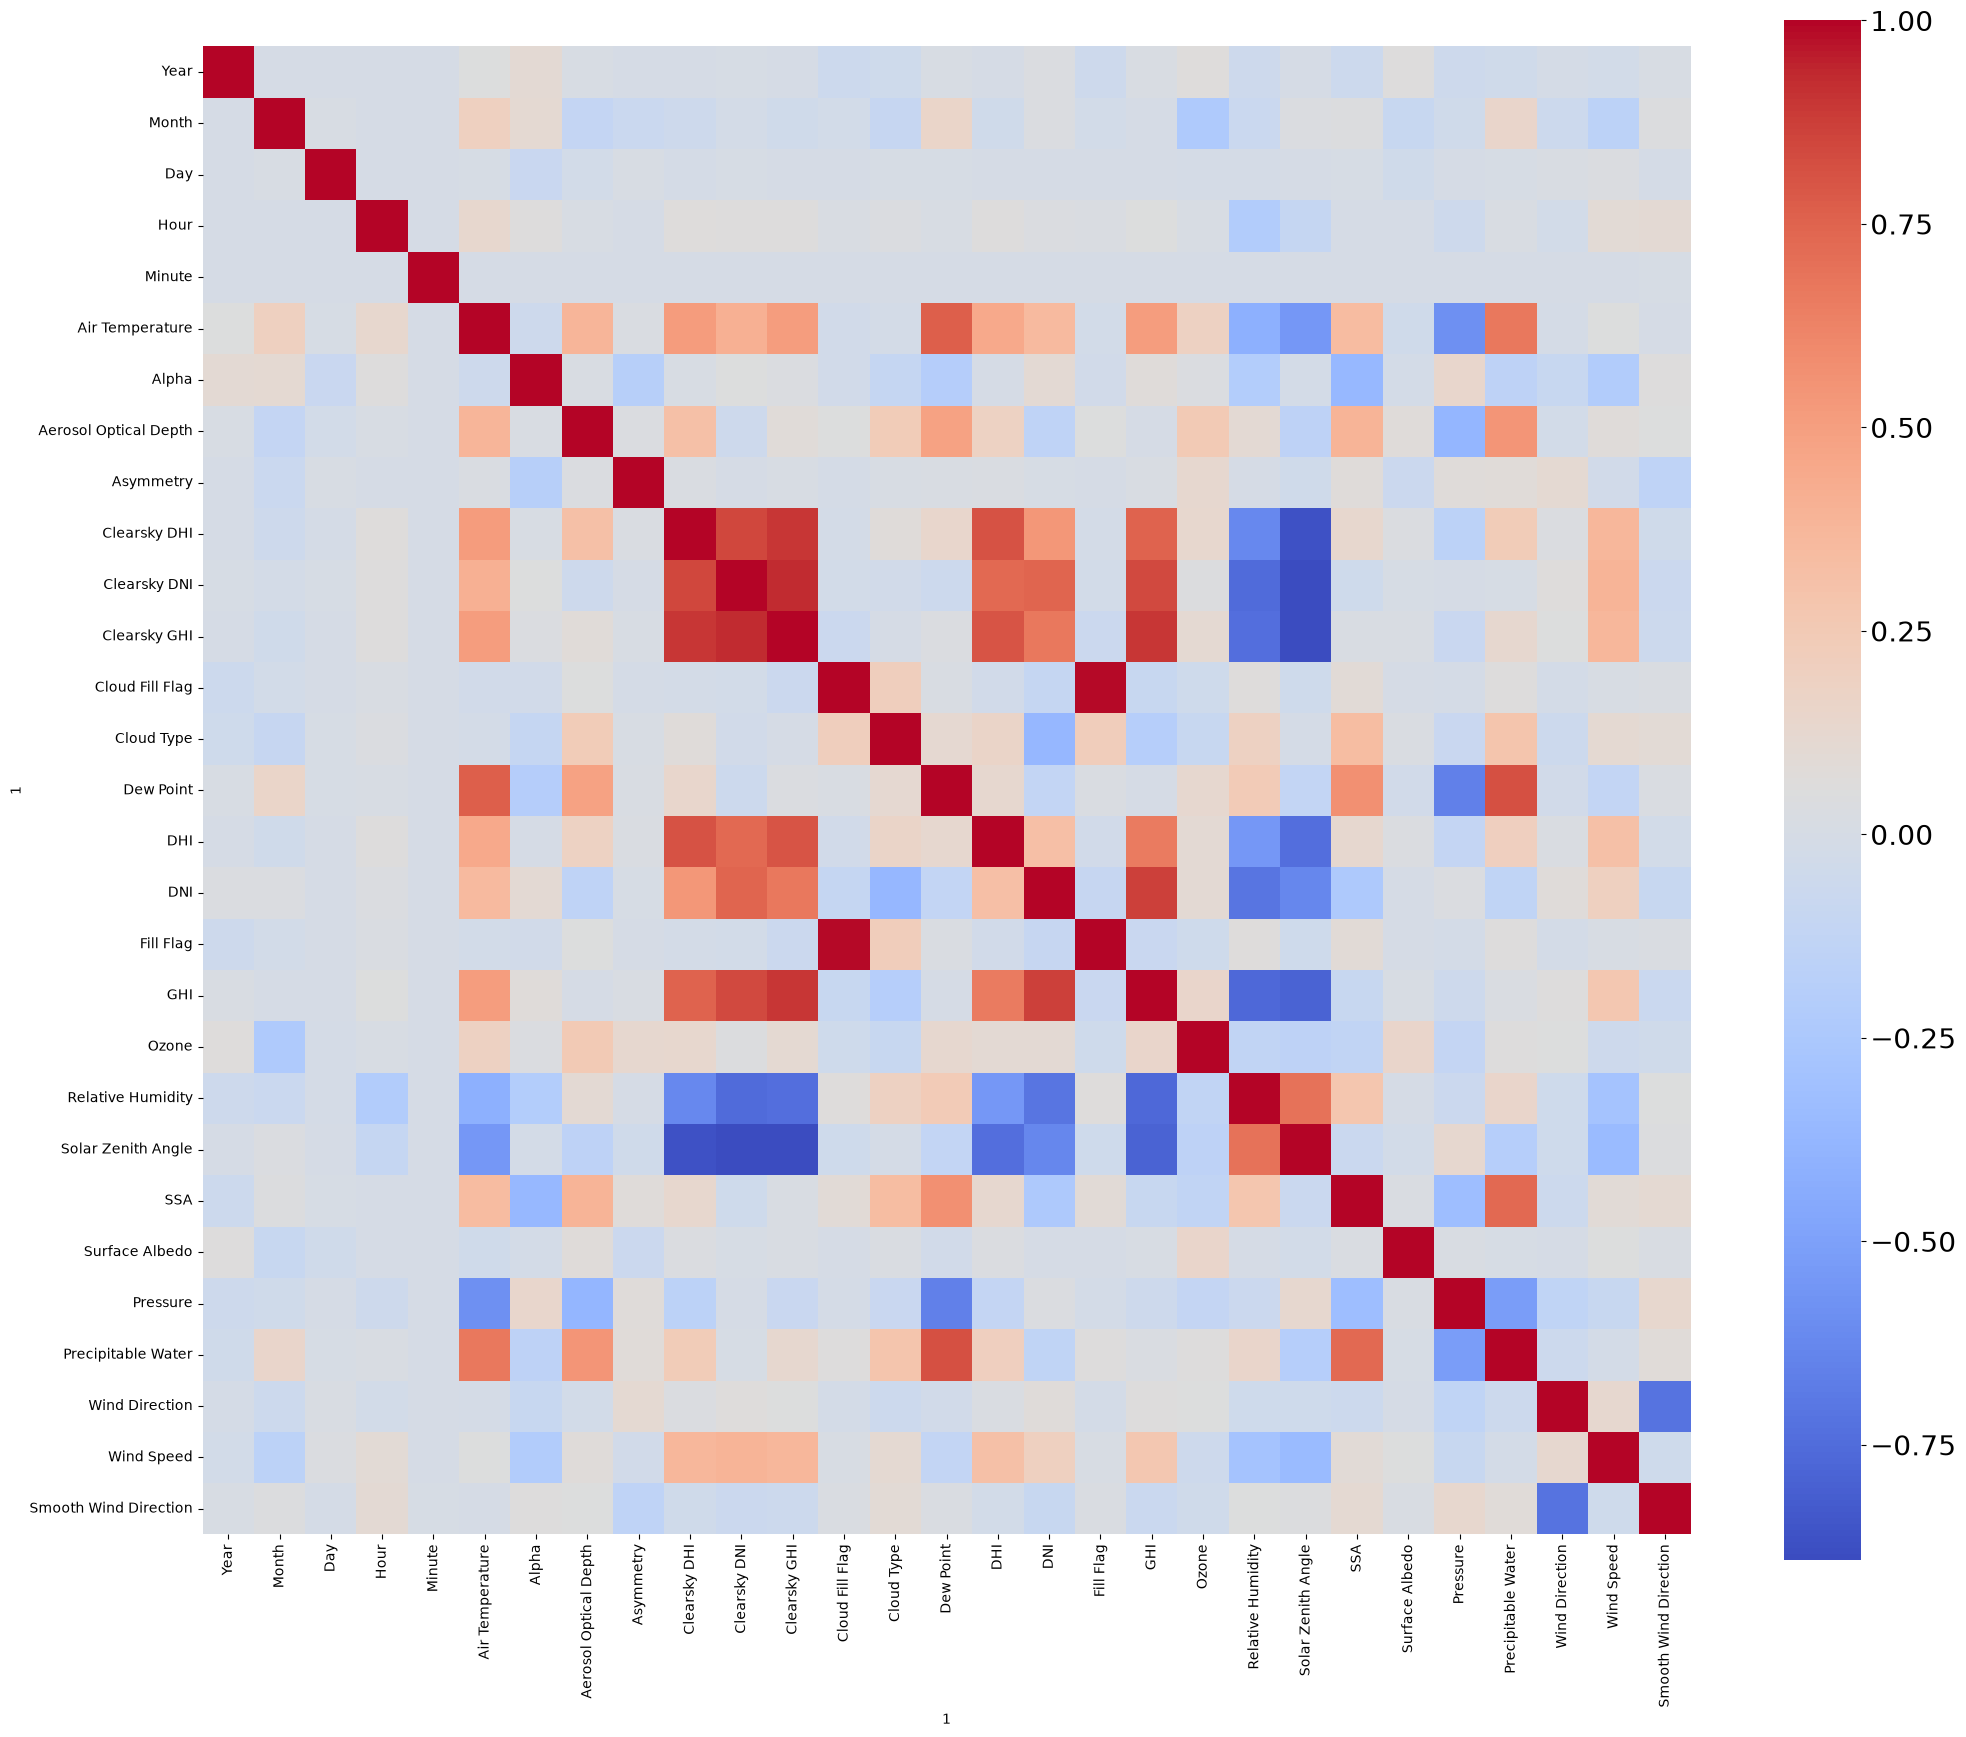

In [22]:
fig, ax = plt.subplots(figsize=(24,20))
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
#num_cols = num_cols.append(merged.columns[-1:])
corr = df[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=False, cmap="coolwarm",ax=ax)
ax.set_aspect(1)